In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import albumentations as A

In [ ]:
class Config:
    img_size = (64, 192)
    in_channels = 3
    embed_dim = 256
    num_heads = 8
    dec_depth = 1
    mlp_ratio = 4.0
    dropout = 0.1
    chars = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"
    max_label_len = 10

    checkpoint_path = "/content/drive/MyDrive/Building-an-Adaptive-License-Plate-Recognition-and-Restoration-System-using-Multi-Task-Deep-Learning/Training/Module_4/Checkpoints/best_model.pth"

config = Config()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
class Tokenizer:
    BOS, EOS, PAD = '[B]', '[E]', '[P]'
    def __init__(self, chars):
        self.itos = [self.EOS, self.BOS, self.PAD] + list(chars)
        self.stoi = {s: i for i, s in enumerate(self.itos)}
    @property
    def eos_id(self): return 0
    @property
    def bos_id(self): return 1
    @property
    def pad_id(self): return 2
    @property
    def num_classes(self): return len(self.itos)

    def decode(self, ids):
        chars = []
        for i in ids.tolist():
            if i == self.eos_id: break
            if i not in [self.bos_id, self.pad_id] and i < len(self.itos):
                chars.append(self.itos[i])
        return ''.join(chars)

tokenizer = Tokenizer(config.chars)

In [ ]:
class ResNetEncoder(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        resnet = models.resnet18(pretrained=False)

        self.backbone_conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=1, padding=3, bias=False)
        self.backbone_conv1.weight = resnet.conv1.weight
        self.backbone_bn1 = resnet.bn1
        self.backbone_relu = resnet.relu

        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2

        self.layer3 = resnet.layer3
        self.layer3[0].conv1.stride = (2, 1)
        self.layer3[0].downsample[0].stride = (2, 1)

        self.layer4 = resnet.layer4
        self.layer4[0].conv1.stride = (2, 1)
        self.layer4[0].downsample[0].stride = (2, 1)

        self.projection = nn.Conv2d(512, embed_dim, kernel_size=1)
        self.pos_embed = nn.Parameter(torch.zeros(1, 1000, embed_dim))

    def forward(self, x):
        x = self.backbone_conv1(x)
        x = self.backbone_bn1(x)
        x = self.backbone_relu(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.projection(x)
        x = x.flatten(2).transpose(1, 2)
        seq_len = x.size(1)
        x = x + self.pos_embed[:, :seq_len, :]
        return x

In [ ]:
class PARSeqDecoder(nn.Module):
    def __init__(self, embed_dim, num_heads, depth, mlp_ratio, dropout, num_classes, max_len):
        super().__init__()
        self.token_embed = nn.Embedding(num_classes, embed_dim)
        self.pos_embed = nn.Parameter(torch.zeros(1, max_len + 2, embed_dim))
        self.dropout = nn.Dropout(dropout)
        dec_layer = nn.TransformerDecoderLayer(d_model=embed_dim, nhead=num_heads,
                                               dim_feedforward=int(embed_dim * mlp_ratio),
                                               dropout=dropout, activation='gelu', batch_first=True)
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, memory, tgt, tgt_mask=None, tgt_pad_mask=None):
        x = self.dropout(self.token_embed(tgt) + self.pos_embed[:, :tgt.size(1)])
        x = self.norm(self.decoder(x, memory, tgt_mask=tgt_mask, tgt_key_padding_mask=tgt_pad_mask))
        return self.head(x)

    def causal_mask(self, sz, device):
        return torch.triu(torch.full((sz, sz), float('-inf'), device=device), diagonal=1)

In [ ]:
class PARSeq(nn.Module):
    def __init__(self, config, tokenizer):
        super().__init__()
        self.tokenizer = tokenizer
        self.max_len = config.max_label_len + 2
        self.encoder = ResNetEncoder(config.embed_dim)
        self.decoder = PARSeqDecoder(config.embed_dim, config.num_heads, config.dec_depth,
                                     config.mlp_ratio, config.dropout, tokenizer.num_classes, config.max_label_len)

    def forward(self, images):
        return self.generate(self.encoder(images))

    @torch.no_grad()
    def generate(self, memory):
        B, device = memory.size(0), memory.device
        tgt = torch.full((B, 1), self.tokenizer.bos_id, dtype=torch.long, device=device)
        for _ in range(self.max_len - 1):
            mask = self.decoder.causal_mask(tgt.size(1), device)
            logits = self.decoder(memory, tgt, tgt_mask=mask)
            next_tok = logits[:, -1].argmax(dim=-1, keepdim=True)
            tgt = torch.cat([tgt, next_tok], dim=1)
            if (next_tok == self.tokenizer.eos_id).all(): break
        return tgt

In [ ]:
def process_image(img_path, img_size):
    img = cv2.imread(str(img_path))
    if img is None: return None, None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img_size
    oh, ow = img.shape[:2]
    scale = min(w/ow, h/oh)
    nw, nh = int(ow*scale), int(oh*scale)
    img_resized = cv2.resize(img, (nw, nh))

    new_img = np.zeros((h, w, 3), dtype=np.uint8)
    y, x = (h-nh)//2, (w-nw)//2
    new_img[y:y+nh, x:x+nw] = img_resized

    norm = A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    img_norm = norm(image=new_img)['image']
    img_tensor = torch.from_numpy(img_norm.transpose(2, 0, 1)).float()

    return img_tensor, new_img

In [ ]:
def predict_and_visualize(model_path, image_paths, device='cuda'):
    # Load Model
    print(f"Loading model from {model_path}...")
    model = PARSeq(config, tokenizer).to(device)
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    # Setup Grid Visualization
    n_images = len(image_paths)
    cols = 3
    rows = (n_images + cols - 1) // cols

    plt.figure(figsize=(15, 4 * rows))

    for i, img_path in enumerate(image_paths):
        # Process
        img_tensor, img_display = process_image(img_path, config.img_size)
        if img_tensor is None:
            print(f"Cannot read {img_path}")
            continue

        # Inference
        img_tensor = img_tensor.unsqueeze(0).to(device)
        with torch.no_grad():
            pred_indices = model(img_tensor)

        pred_text = tokenizer.decode(pred_indices[0])

        # Visualize
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img_display)

        # Vẽ khung kết quả
        plt.title(f"Pred: {pred_text}", fontsize=14, color='darkblue', fontweight='bold',
                  bbox=dict(facecolor='yellow', alpha=0.3, pad=5))
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
test_images = [
    "/content/drive/MyDrive/Building-an-Adaptive-License-Plate-Recognition-and-Restoration-System-using-Multi-Task-Deep-Learning/Training/Module_4/Test/test_1.png",
    "/content/drive/MyDrive/Building-an-Adaptive-License-Plate-Recognition-and-Restoration-System-using-Multi-Task-Deep-Learning/Training/Module_4/Test/test_2.png",
    "/content/drive/MyDrive/Building-an-Adaptive-License-Plate-Recognition-and-Restoration-System-using-Multi-Task-Deep-Learning/Training/Module_4/Test/test_3.jpg",
    "/content/drive/MyDrive/Building-an-Adaptive-License-Plate-Recognition-and-Restoration-System-using-Multi-Task-Deep-Learning/Training/Module_4/Test/test_4.jpg",
    "/content/drive/MyDrive/Building-an-Adaptive-License-Plate-Recognition-and-Restoration-System-using-Multi-Task-Deep-Learning/Training/Module_4/Test/test_5.jpg",
    "/content/drive/MyDrive/Building-an-Adaptive-License-Plate-Recognition-and-Restoration-System-using-Multi-Task-Deep-Learning/Training/Module_4/Test/test_6.jpg"
]

Loading model from /content/drive/MyDrive/Building-an-Adaptive-License-Plate-Recognition-and-Restoration-System-using-Multi-Task-Deep-Learning/Training/Module_4/Checkpoints/best_model.pth...


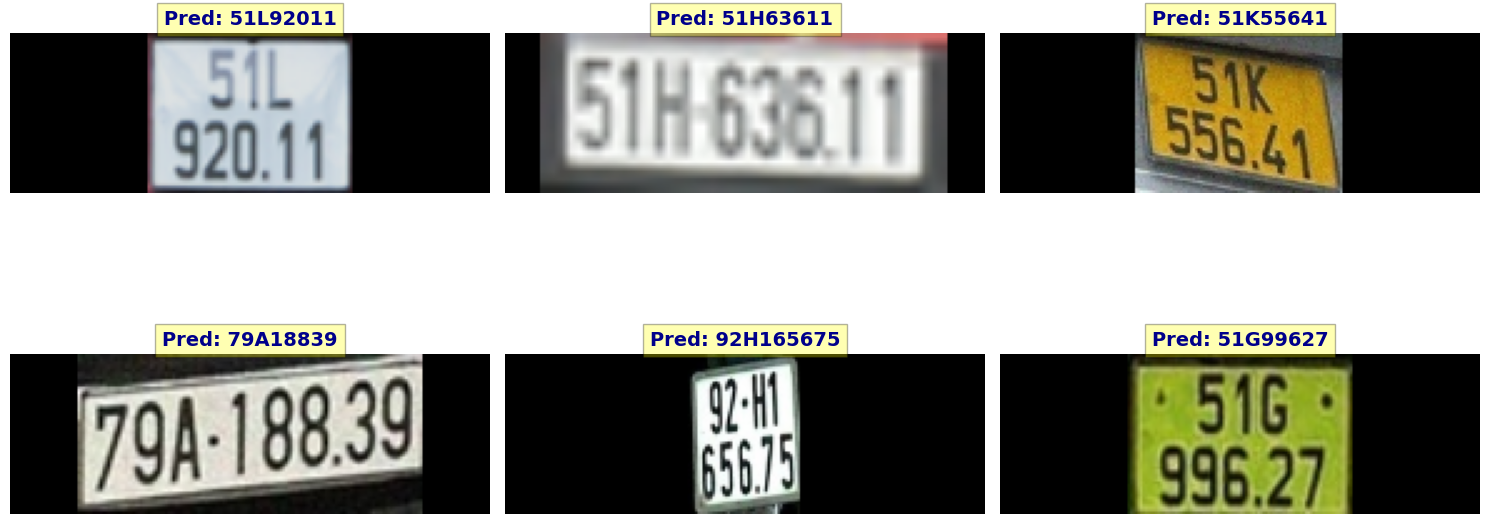

In [ ]:
try:
    predict_and_visualize(config.checkpoint_path, test_images, device)
except FileNotFoundError:
    print("Check checkpoints.")